Using cache found in C:\Users\sahar/.cache\torch\hub\pytorch_vision_v0.10.0



=== ENCODING REFERENCES ===
coke-can.png encoded

=== RUN YOLO ===

0: 448x640 4 cups, 74.4ms
Speed: 3.5ms preprocess, 74.4ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Detected objects: 4

=== MATCHING ===
[0] similarity = 0.792
[1] similarity = 0.831
[2] similarity = 0.796
[3] similarity = 0.800

FINAL COUNT = 4



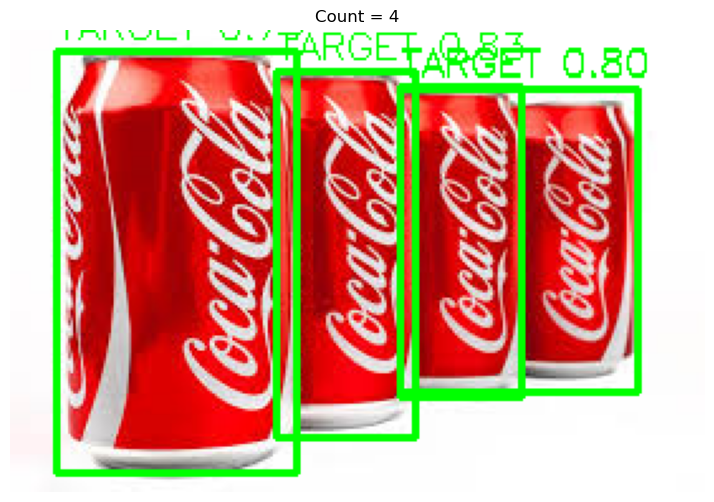

Saved result.jpg


In [3]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load models
# -----------------------------
yolo = YOLO("yolov8n.pt")

encoder = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
encoder = torch.nn.Sequential(*list(encoder.children())[:-1])
encoder.eval()

# -----------------------------
# 2. Encode functions
# -----------------------------
def preprocess(img):
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.transpose(img, (2, 0, 1))
    return torch.tensor(img, dtype=torch.float32).unsqueeze(0)

def encode(img):
    with torch.no_grad():
        x = preprocess(img)
        feat = encoder(x).squeeze().numpy()
    return feat / np.linalg.norm(feat)

# -----------------------------
# 3. Load reference images
# -----------------------------
reference_paths = [
    "coke-can.png",
]

ref_embeddings = []

print("\n=== ENCODING REFERENCES ===")
for path in reference_paths:
    img = cv2.imread(path)
    if img is None:
        raise Exception(f"โหลด reference ไม่ได้: {path}")

    emb = encode(img)
    ref_embeddings.append(emb)
    print(f"{path} encoded")

# -----------------------------
# 4. Load scene
# -----------------------------
scene = cv2.imread("coke-cans.jpg")
if scene is None:
    raise Exception("โหลด scene ไม่ได้")

# -----------------------------
# 5. Detection
# -----------------------------
print("\n=== RUN YOLO ===")
results = yolo(scene, conf=0.1)[0]
boxes = results.boxes.xyxy

print(f"Detected objects: {len(boxes)}")

# -----------------------------
# 6. Matching + Counting
# -----------------------------
count = 0
threshold = 0.7   # ปรับได้

print("\n=== MATCHING ===")

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box.tolist())
    crop = scene[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    emb = encode(crop)

    # 🔥 ใช้ max similarity (ดีที่สุดสำหรับ few-shot)
    sims = [np.dot(emb, ref) for ref in ref_embeddings]
    sim = max(sims)

    print(f"[{i}] similarity = {sim:.3f}")

    # -----------------------------
    # Decision
    # -----------------------------
    if sim > threshold:
        count += 1
        color = (0, 255, 0)
        label = f"TARGET {sim:.2f}"
    else:
        color = (0, 0, 255)
        label = f"OTHER {sim:.2f}"

    # draw box
    cv2.rectangle(scene, (x1, y1), (x2, y2), color, 2)
    cv2.putText(scene, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# -----------------------------
# 7. Result
# -----------------------------
print("\n======================")
print(f"FINAL COUNT = {count}")
print("======================\n")

# show image
scene_rgb = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(scene_rgb)
plt.title(f"Count = {count}")
plt.axis("off")
plt.show()

# save result
cv2.imwrite("result.jpg", scene)
print("Saved result.jpg")